# Hago estudio dqdv y ajustes sobre 10C


In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl

import numpy as np
import pandas as pd

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
# --- carga de datos ---
path_json = "../tmp/NMC-10-cada3.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 67


## Graficos para observar

In [3]:
# --- Selección de ciclos ---
ciclos_sel = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 66 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]


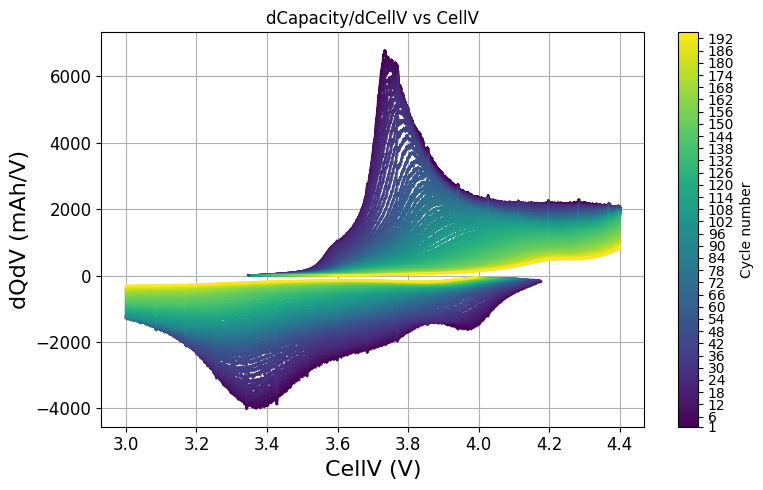

In [4]:
pl.plot_n_cycles_dqdv(ciclos_sel, dict_ciclos_sep)


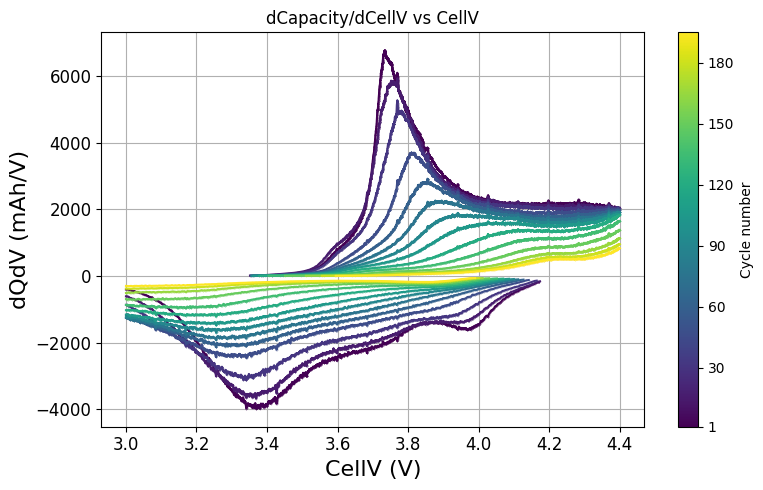

In [5]:
ciclos_grafico = [ciclos_sel[i] for i in range(len(ciclos_sel)) if i % 5 == 0]

pl.plot_n_cycles_dqdv(ciclos_grafico, dict_ciclos_sep)

Salto promedio entre elementos consecutivos (resolución) de V_ch: 0.0001 V
Ventana de suavizado: 15 puntos
Salto promedio entre elementos consecutivos (resolución) de V_dis: 0.0004265477057538236
Ventana de suavizado: 5 puntos
Salto promedio entre elementos consecutivos (resolución) de V_ch: 0.0001 V
Ventana de suavizado: 15 puntos
Salto promedio entre elementos consecutivos (resolución) de V_dis: 0.00042579004722121327
Ventana de suavizado: 5 puntos
Salto promedio entre elementos consecutivos (resolución) de V_ch: 0.0001 V
Ventana de suavizado: 15 puntos
Salto promedio entre elementos consecutivos (resolución) de V_dis: 0.00042767272727272726
Ventana de suavizado: 5 puntos
Salto promedio entre elementos consecutivos (resolución) de V_ch: 0.0001 V
Ventana de suavizado: 15 puntos
Salto promedio entre elementos consecutivos (resolución) de V_dis: 0.00043198826118855463
Ventana de suavizado: 5 puntos
Salto promedio entre elementos consecutivos (resolución) de V_ch: 0.0001 V
Ventana de sua

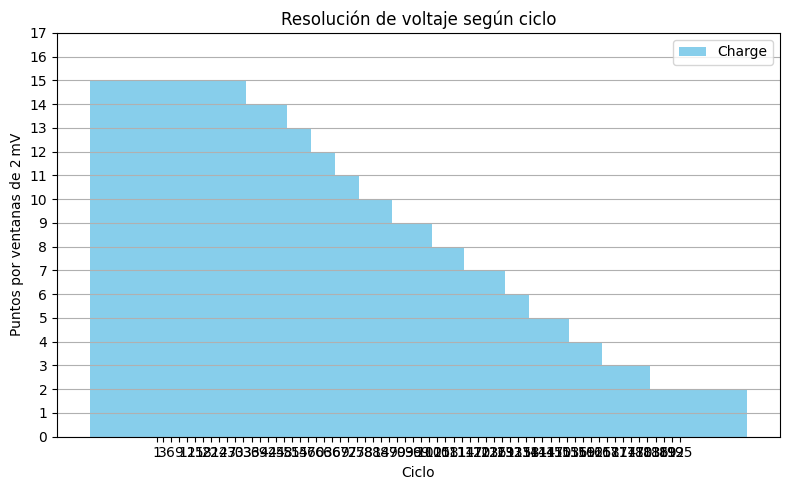

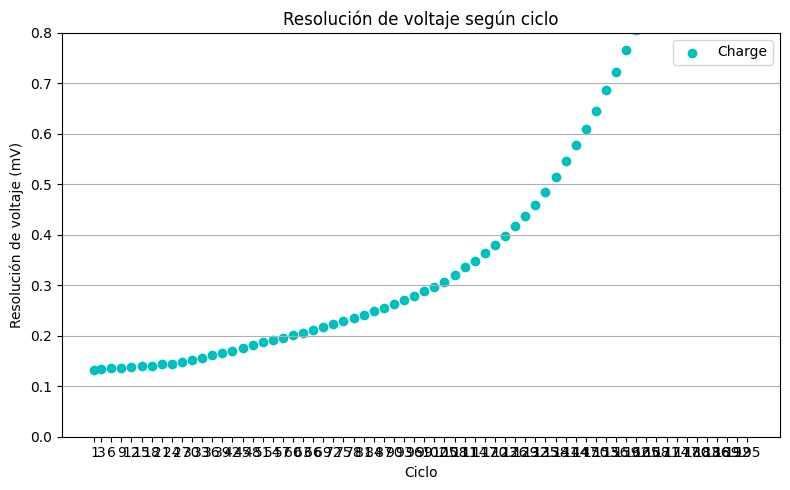

Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2785 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.8341451524399122 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2785 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.8343100864511439 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2785 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.8342576600363636 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2785 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.8344430875641964 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2784 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.8346275583488283 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_ch: 0.2785 mAh
Salto promedio entre elementos consecutivos (resolución) de Q_dis: 0.834113532188679 mAh

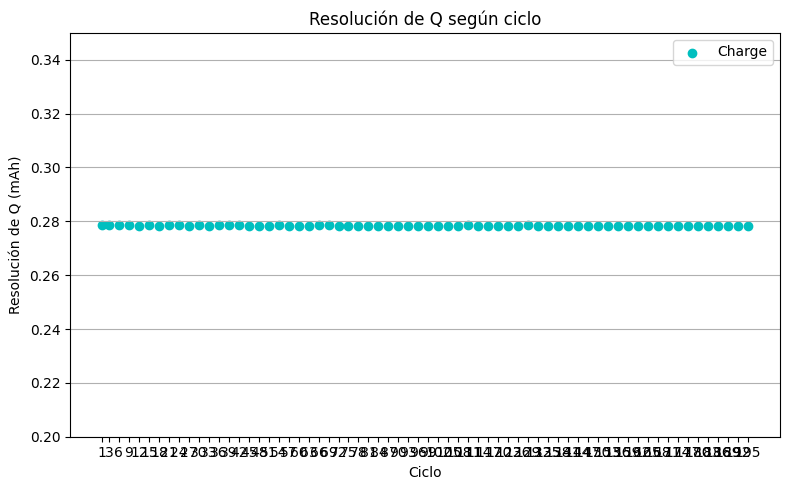

In [9]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel, dict_ciclos_sep)

utl.resolucion_Q(ciclos_sel, dict_ciclos_sep)

## Pruebo parametros filtros para calcular derivada

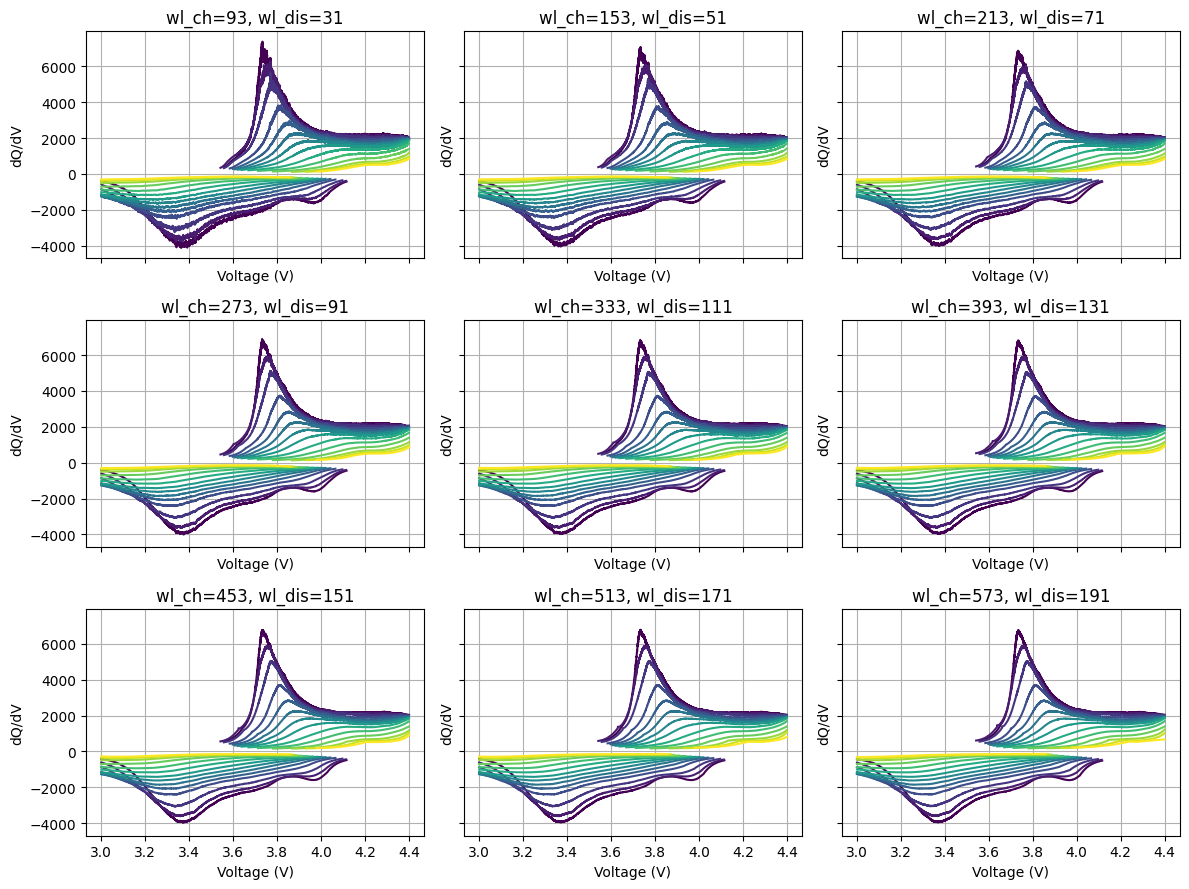

In [6]:
dr.plot_dqdv_muchos_wl(ciclos_grafico, dict_ciclos_sep, wl_values=[31,51,71,91,111,131,151,171,191], truncar_values=(20,60))

## Calculo derivada con los parámetros dados

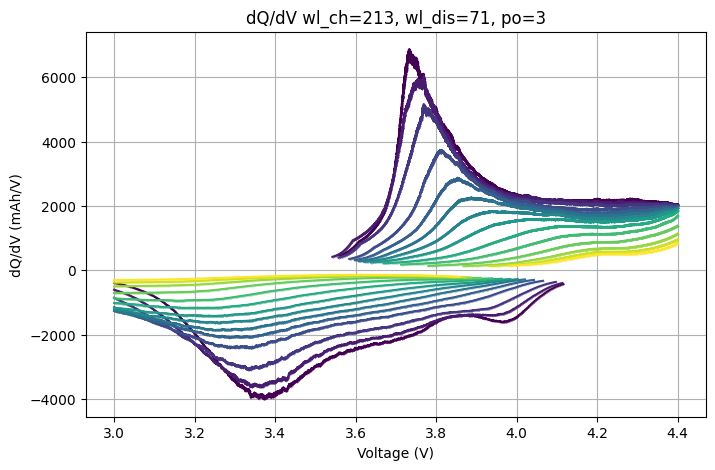

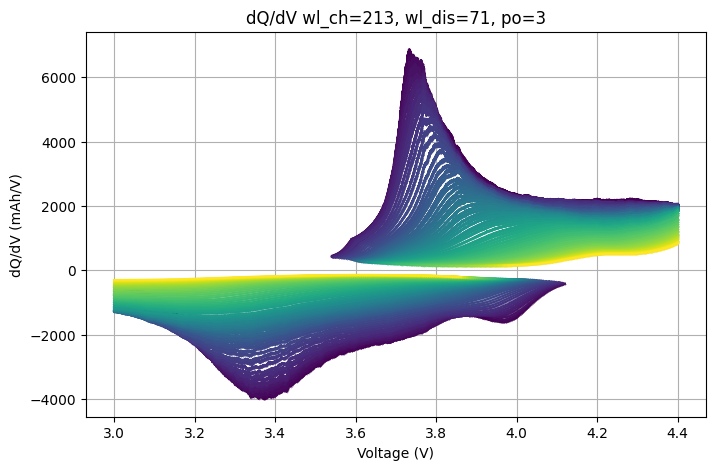

In [9]:
# --- Trunco datos y calculo derivada ---


# --- Parámetros para el cálculo de la derivada ---
# En este conjunto de datos, la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

# Para NMC-20:
#   charge (wl = 153, truncar los n=30 puntos iniciales)
#   discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

# Para NMC-10:
#   charge (wl = 213, truncar los n=30 puntos iniciales)
#   discharge (wl = 71 = 153 / 3, truncar los n=10=30/3 puntos finales)



# --- Calculo derivada dQdV ---
diccio = dict_ciclos_sep
diccio = dr.truncar_señal(ciclos_grafico, dict_ciclos_sep, n_dis=20, n_ch=60)
diccio =  dr.plot_dqdV(ciclos_grafico, diccio, wl_dis=71, wl_ch=213)

diccio = dr.truncar_señal(ciclos_sel, dict_ciclos_sep, n_dis=20, n_ch=60)
diccio =  dr.plot_dqdV(ciclos_sel, diccio, wl_dis=71, wl_ch=213)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

# Ajustes sobre dqdv 10C

In [12]:
# [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]

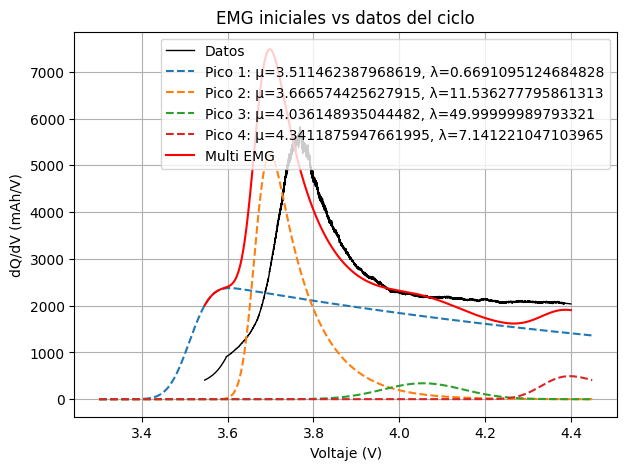

In [10]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio[21]['Ch']
param_guess = [(5400, 3.51, 0.04, 0.4), 
               (1000, 3.67, 0.03, 9), 
               (200, 4.0, 0.1, 5), 
               (220, 4.34, 0.09, 6)]

param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828),
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]


ft.plot_emg_guess(df_ch, param_guess)

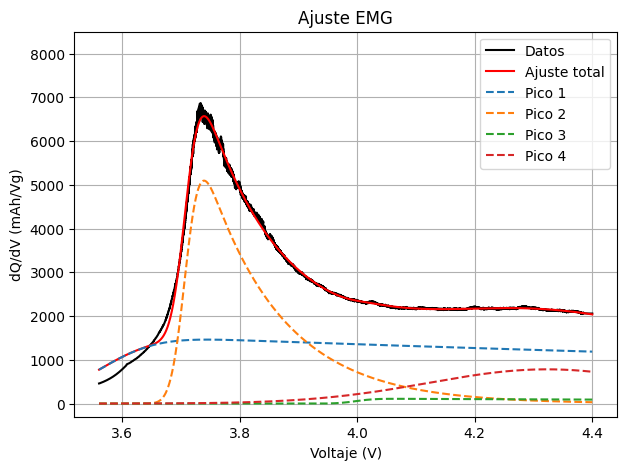

In [13]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
p_ini_peaks = [
    (5000, 3.51, 0.02, 0.4),
    (1000, 3.67, 0.03, 9),
    (200, 4.0, 0.1, 5),
    (220, 4.34, 0.09, 6)
]

n_peaks = len(p_ini_peaks)

# Construir p_ini_emg y bounds automáticamente
p_ini_emg = []
lb, ub = [], []

for a0, mu0, sigma0, lam0 in p_ini_peaks:
    p_ini_emg += [a0, mu0, sigma0, lam0]
    lb += [0, mu0-0.05, 1e-6, 0]
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]

bounds_emg = (lb, ub)

# Ajuste del ciclo 1 de carga
df_ch_1 = diccio[1]['Ch']
p_opt_1, cov_1 = ft.fit_emg_ciclo(df_ch_1, p_ini_emg, bounds_emg)
ft.plot_emg_fit(df_ch_1, p_opt_1)